# Exercise 1

In [2]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

In [3]:
df = pd.read_csv('date_colesterol.csv')

Plot the data

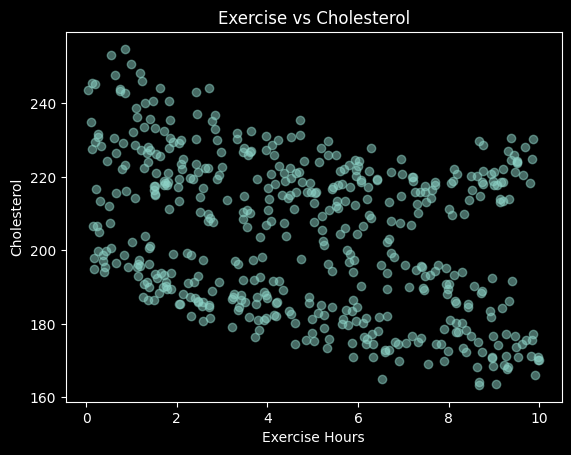

In [4]:
# Visualize
plt.scatter(df['Ore_Exercitii'], df['Colesterol'], alpha=0.5)
plt.xlabel('Exercise Hours')
plt.ylabel('Cholesterol')
plt.title('Exercise vs Cholesterol')
plt.show()

In [5]:
# Extract data
x = df['Ore_Exercitii'].values
y = df['Colesterol'].values

## Defining the model

In [6]:
with pm.Model() as cholesterol_model:
    # 1. Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=200, sigma=50) # Expected intercept
    beta = pm.Normal("beta", mu=0, sigma=10)     # Expected slope
    sigma = pm.HalfNormal("sigma", sigma=20)     # Expected noise

    # 2. Expected value of outcome (Linear Regression Equation)
    mu = alpha + beta * x

    # 3. Likelihood (sampling distribution) of observations
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # 4. Posterior sampling
    trace = pm.sample(2000, chains=4, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.


Results

         mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  216.58  1.68  213.47   219.71       0.03     0.02   3984.17   4056.89   
beta    -2.53  0.30   -3.10    -1.97       0.00     0.00   3893.71   3828.45   
sigma   19.38  0.62   18.24    20.52       0.01     0.01   4863.55   4249.64   

       r_hat  
alpha    1.0  
beta     1.0  
sigma    1.0  


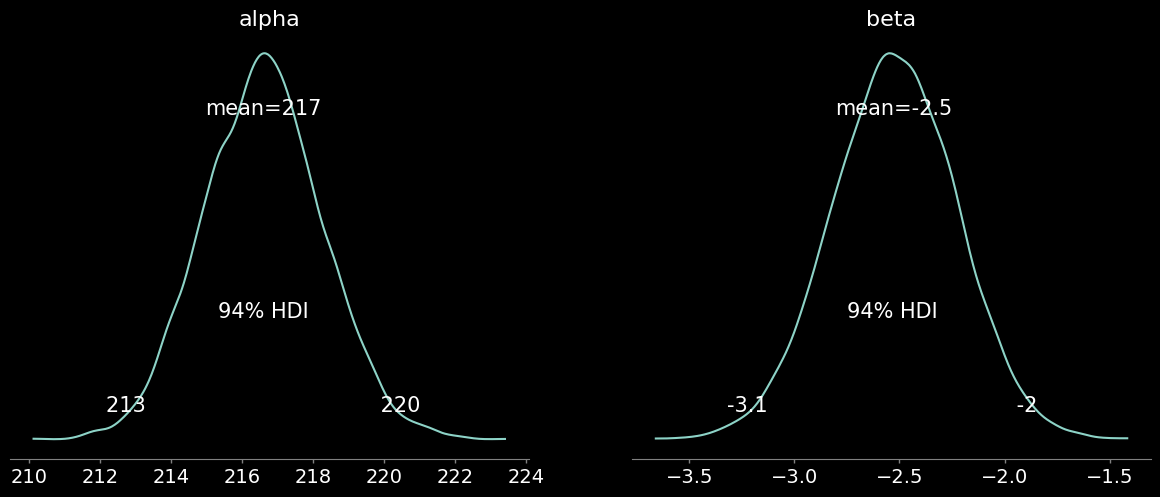

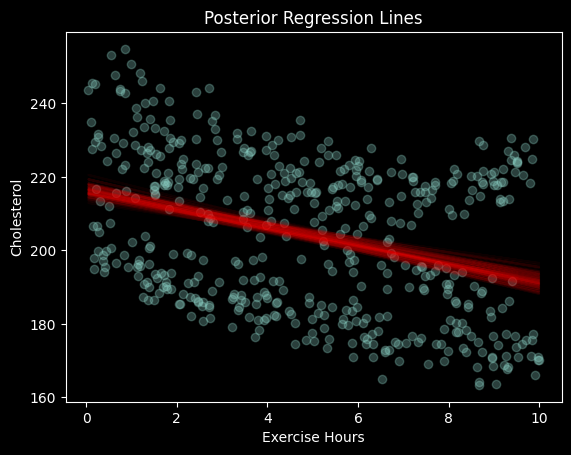

In [7]:
# Summary statistics
print(az.summary(trace, round_to=2))

# Plot the posterior distributions
az.plot_posterior(trace, var_names=["alpha", "beta"])
plt.show()

# Plot the regression line over the data
plt.scatter(x, y, alpha=0.3, label='Data')
post = az.extract(trace, num_samples=100) # Get 100 posterior samples
for i in range(100):
    plt.plot(x, post['alpha'][i].values + post['beta'][i].values * x, color='red', alpha=0.05)

plt.xlabel('Exercise Hours')
plt.ylabel('Cholesterol')
plt.title('Posterior Regression Lines')
plt.show()

Estimating the Regression Coeficients using $K \in \{3, 4, 5\}$

In [10]:
k_values = [3, 4, 5]
traces_k = {}

for k in k_values:
    print(f"Running Mixture Model with K={k} subpopulations...")
    with pm.Model() as model_k:
        # Weights for each subpopulation
        weights = pm.Dirichlet("w", a=np.ones(k))
        
        # Regression coefficients for each subpopulation
        alpha = pm.Normal("alpha", mu=200, sigma=50, shape=k)
        beta = pm.Normal("beta", mu=0, sigma=10, shape=k)
        sigma = pm.HalfNormal("sigma", sigma=20, shape=k)
        
        # Expected value (linear regression) for each component
        mu = alpha + beta * x[:, None]
        
        # Mixture Likelihood
        pm.Mixture("y_obs", w=weights, comp_dists=pm.Normal.dist(mu=mu, sigma=sigma), observed=y)
        
        # Sampling
        trace_k = pm.sample(1000, chains=2, return_inferencedata=True, progressbar=True)
        pm.compute_log_likelihood(trace_k)
        traces_k[k] = trace_k
        
    print(f"\nRegression Coefficients for K={k}:")
    print(az.summary(trace_k, var_names=["alpha", "beta"], round_to=2))


Running Mixture Model with K=3 subpopulations...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, alpha, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [w, alpha, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 49 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Regression Coefficients for K=5:
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  211.56  19.36  194.93   252.04      11.21     5.90      3.27   
alpha[1]  217.21  24.66  194.49   254.46      14.69     2.62      3.68   
alpha[2]  222.94  15.13  198.35   253.56       1.85     2.76     62.35   
alpha[3]  219.24  17.74  194.96   251.41       2.23     1.75     64.80   
alpha[4]  230.79  21.15  197.03   260.13       7.44     2.04      6.97   
beta[0]    -2.83   2.72   -7.79     1.69       1.18     1.07      5.56   
beta[1]    -4.41   2.81   -8.93    -1.21       1.13     0.69      6.35   
beta[2]    -1.80   3.17   -7.83     2.42       0.69     0.57     38.74   
beta[3]    -1.98   3.42   -8.23     2.49       0.61     0.32     31.29   
beta[4]    -3.59   3.97   -8.62     2.06       1.28     0.25      9.06   

          ess_tail  r_hat  
alpha[0]     17.96   1.77  
alpha[1]     94.95   1.73  
alpha[2]     79.00   1.09  
alpha[3]    108.67   1.05  
alpha[4]   

# Nr of subpopulations representing the data (WAIC or LOO) -> WAIC

WAIC Comparison:
   rank    elpd_waic     p_waic  elpd_diff        weight         se       dse  \
5     0 -2053.322390  20.688365   0.000000  7.622622e-01  12.163562  0.000000   
4     1 -2054.637968  17.147060   1.315579  3.820728e-16  12.190452  1.093039   
3     2 -2054.903473  10.561428   1.581083  2.377378e-01  12.443456  2.468113   

   warning scale  
5    False   log  
4    False   log  
3    False   log  


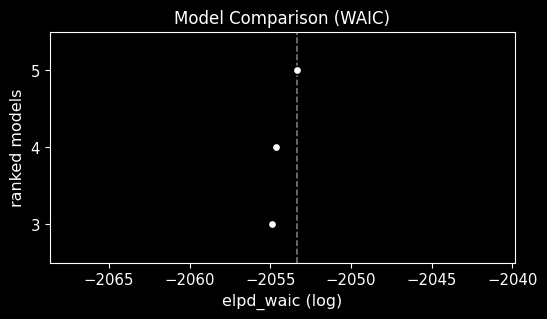

In [11]:
comp_waic = az.compare(traces_k, ic="waic")
print("WAIC Comparison:")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("Model Comparison (WAIC)")
plt.show()